In [19]:
import json
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open("training_data_shortest_path_mixed_55_15_reps100.json", "r") as f:
    training_data = json.load(f)

len(training_data)

6000

In [3]:
training_data[0].keys()

dict_keys(['n_nodes', 'n_arcs', 'density', 'source', 'sink', 'attack_limit', 'problem_type', 'u', 'v', 'penalty', 'interdictable', 'attack', 'path_length', 'penalty_high', 'mip_solve_time', 'solver_status', 'termination_condition', 'dist', 'cost_high', 'graph_seed', 'replication', 'attack_budget', 'topology'])

In [5]:
train_cost = []
train_penalty = []

for sample in training_data:
    train_cost.extend(sample["dist"])
    train_penalty.extend(sample["penalty"])

train_cost = np.array(train_cost)
train_penalty = np.array(train_penalty)

In [7]:
with open("evaluation_graphs/shortest_path_value_ood_graphs.pkl", "rb") as f:
    value_ood_graphs = pickle.load(f)

len(value_ood_graphs)

360

In [9]:
list(value_ood_graphs[0]["G"].edges(data=True))[:3]

[(0, 1, {'dist': 25, 'penalty': 23, 'capacity': 18}),
 (0, 5, {'dist': 12, 'penalty': 43, 'capacity': 8}),
 (0, 17, {'dist': 40, 'penalty': 44, 'capacity': 17})]

In [11]:
ood_cost = []
ood_penalty = []

for item in value_ood_graphs:

    G = item["G"]

    for u, v, data in G.edges(data=True):
        ood_cost.append(data["dist"])
        ood_penalty.append(data["penalty"])

ood_cost = np.array(ood_cost)
ood_penalty = np.array(ood_penalty)

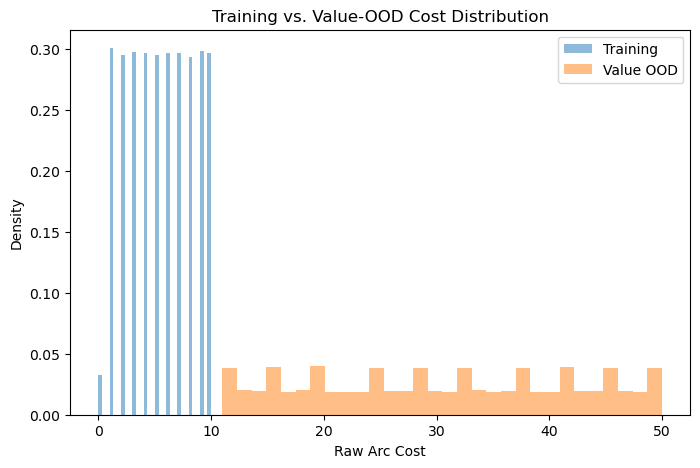

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_cost,
    bins=30,
    alpha=0.5,
    density=True,
    label="Training"
)

plt.hist(
    ood_cost,
    bins=30,
    alpha=0.5,
    density=True,
    label="Value OOD"
)

plt.xlabel("Raw Arc Cost")
plt.ylabel("Density")
plt.title("Training vs. Value-OOD Cost Distribution")
plt.legend()

plt.show()

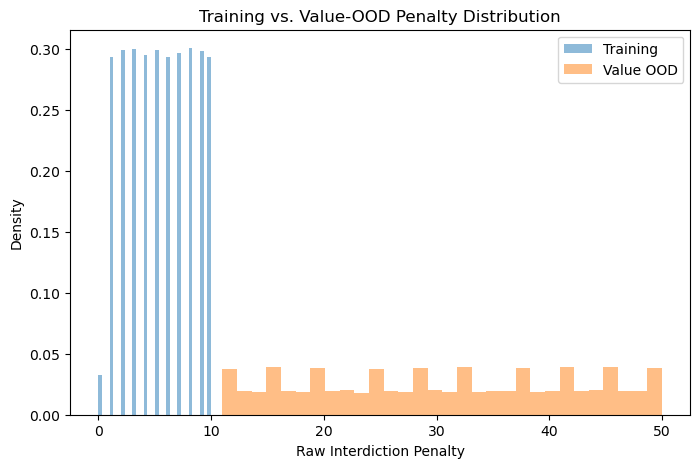

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_penalty,
    bins=30,
    alpha=0.5,
    density=True,
    label="Training"
)

plt.hist(
    ood_penalty,
    bins=30,
    alpha=0.5,
    density=True,
    label="Value OOD"
)

plt.xlabel("Raw Interdiction Penalty")
plt.ylabel("Density")
plt.title("Training vs. Value-OOD Penalty Distribution")
plt.legend()

plt.show()

In [17]:
train_cost_norm = []
train_penalty_norm = []

for sample in training_data:

    cost = np.array(sample["dist"], dtype=float)
    penalty = np.array(sample["penalty"], dtype=float)

    train_cost_norm.extend(
        cost / cost.max()
    )

    train_penalty_norm.extend(
        penalty / penalty.max()
    )

train_cost_norm = np.array(train_cost_norm)
train_penalty_norm = np.array(train_penalty_norm)

In [19]:
ood_cost_norm = []
ood_penalty_norm = []

for item in value_ood_graphs:

    G = item["G"]

    cost = np.array([
        data["dist"]
        for _, _, data in G.edges(data=True)
    ])

    penalty = np.array([
        data["penalty"]
        for _, _, data in G.edges(data=True)
    ])

    ood_cost_norm.extend(
        cost / cost.max()
    )

    ood_penalty_norm.extend(
        penalty / penalty.max()
    )

ood_cost_norm = np.array(ood_cost_norm)
ood_penalty_norm = np.array(ood_penalty_norm)

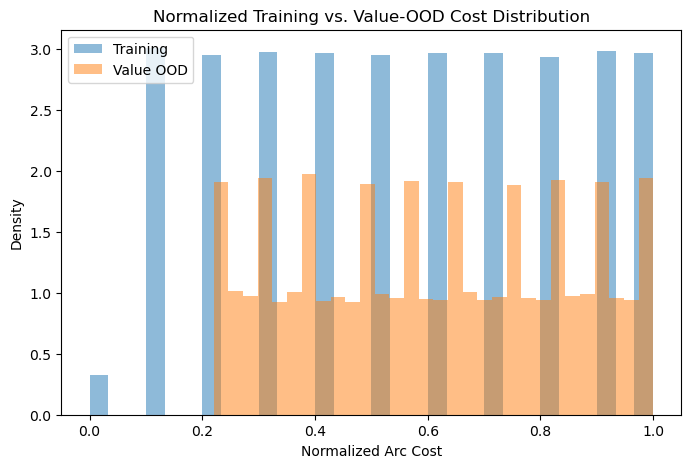

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_cost_norm,
    bins=30,
    alpha=0.5,
    density=True,
    label="Training"
)

plt.hist(
    ood_cost_norm,
    bins=30,
    alpha=0.5,
    density=True,
    label="Value OOD"
)

plt.xlabel("Normalized Arc Cost")
plt.ylabel("Density")
plt.title("Normalized Training vs. Value-OOD Cost Distribution")
plt.legend()

plt.show()

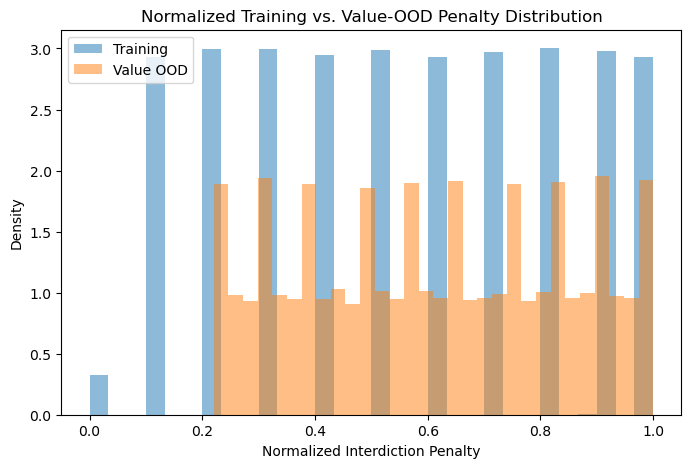

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_penalty_norm,
    bins=30,
    alpha=0.5,
    density=True,
    label="Training"
)

plt.hist(
    ood_penalty_norm,
    bins=30,
    alpha=0.5,
    density=True,
    label="Value OOD"
)

plt.xlabel("Normalized Interdiction Penalty")
plt.ylabel("Density")
plt.title("Normalized Training vs. Value-OOD Penalty Distribution")
plt.legend()

plt.show()

In [25]:
def describe(name, x):
    print(
        f"{name:25s} "
        f"min={x.min():.3f}  "
        f"mean={x.mean():.3f}  "
        f"median={np.median(x):.3f}  "
        f"max={x.max():.3f}"
    )

describe("Training cost", train_cost_norm)
describe("OOD cost", ood_cost_norm)

print()

describe("Training penalty", train_penalty_norm)
describe("OOD penalty", ood_penalty_norm)

Training cost             min=0.000  mean=0.544  median=0.500  max=1.000
OOD cost                  min=0.220  mean=0.609  median=0.600  max=1.000

Training penalty          min=0.000  mean=0.544  median=0.500  max=1.000
OOD penalty               min=0.220  mean=0.611  median=0.620  max=1.000


In [3]:
# LOAD DATA

nodes = pd.read_csv("node_data.csv")
arcs = pd.read_csv("arc_data.csv")

print(f"Nodes: {len(nodes)}")
print(f"Arcs: {len(arcs)}")

Nodes: 1054
Arcs: 3250


In [5]:
# IDENTIFY SUPPLY AND DEMAND NODES

supply_nodes = nodes.loc[nodes["supply"] > 0, "node"].tolist()

demand_nodes = nodes.loc[nodes["supply"] < 0, "node"].tolist()

print("\nSupply nodes:")
print(supply_nodes)

print("\nDemand nodes:")
print(demand_nodes)

print(f"\nPossible supply-demand pairs: {len(supply_nodes) * len(demand_nodes)}")


Supply nodes:
[1, 2, 3, 4, 5, 10]

Demand nodes:
[6, 7, 8, 9, 1077]

Possible supply-demand pairs: 30


In [9]:
# BUILD DIRECTED GRAPH

G = nx.DiGraph()

G.add_nodes_from(nodes["node"])

for _, row in arcs.iterrows():

    u = int(row["from_node"])
    v = int(row["to_node"])

    G.add_edge(u, v,cost=float(row["cost"]), capacity=float(row["capacity"]), transport_mode=row["transport_mode"])


# BASIC NETWORK INFORMATION

n = G.number_of_nodes()
m = G.number_of_edges()
max_cost = arcs["cost"].max()

disconnection_penalty = n * max_cost

print(f"n = {n}")
print(f"m = {m}")
print(f"m/n = {m/n:.3f}")
print(f"Maximum arc cost = {max_cost:.4f}")
print(f"Disconnected-case penalty = {disconnection_penalty:.4f}")

n = 1054
m = 3250
m/n = 3.083
Maximum arc cost = 232.0612
Disconnected-case penalty = 244592.4742


In [11]:
# CALCULATE DETOUR PENALTIES

results = []

# fixed list because graph is temporarily modified
edge_list = list(G.edges(data=True))

for u, v, data in edge_list:

    original_cost = data["cost"]

    # save all attributes before removing edge
    edge_attributes = data.copy()

    G.remove_edge(u, v)

    try:

        alternative_cost = nx.shortest_path_length(G,source=u,target=v,weight="cost")
        penalty = alternative_cost - original_cost
        alternative_exists = True
        
    except nx.NetworkXNoPath:

        alternative_cost = np.inf
        penalty = disconnection_penalty
        alternative_exists = False

    # restore original edge and attributes
    G.add_edge(u, v, **edge_attributes)

    results.append({
        "from_node": u,
        "to_node": v,
        "transport_mode": edge_attributes["transport_mode"],
        "cost": original_cost,
        "alternative_cost": alternative_cost,
        "alternative_exists": alternative_exists,
        "penalty": penalty})


penalty_df = pd.DataFrame(results)

In [13]:
# DIAGNOSTICS

print("\nAll penalties:")
print(penalty_df["penalty"].describe())

print("\nAlternative route counts:")
print(penalty_df["alternative_exists"].value_counts())

print("\nPercent with an alternative route:")
print(100 * penalty_df["alternative_exists"].mean())

print("\nPercent with NO alternative route:")
print(100 * (~penalty_df["alternative_exists"]).mean())


All penalties:
count      3250.000000
mean      11308.712429
std       51323.495994
min         -36.667200
25%           1.689498
50%           5.780724
75%          28.168977
max      244592.474234
Name: penalty, dtype: float64

Alternative route counts:
alternative_exists
True     3100
False     150
Name: count, dtype: int64

Percent with an alternative route:
95.38461538461539

Percent with NO alternative route:
4.615384615384616


In [15]:
# FINITE DETOUR PENALTIES ONLY

detours = penalty_df[penalty_df["alternative_exists"]].copy()

print("\nDetour-derived penalties:")
print(detours["penalty"].describe())


# ROAD VS RAIL

print("\nPenalty summary by transportation mode:")

print(detours.groupby("transport_mode")["penalty"].describe())


Detour-derived penalties:
count    3100.000000
mean       20.788471
std        38.103688
min       -36.667200
25%         1.556916
50%         5.136765
75%        20.502396
max       323.052188
Name: penalty, dtype: float64

Penalty summary by transportation mode:
                 count       mean        std        min       25%        50%  \
transport_mode                                                                 
rail             302.0  33.112131  45.469347   0.153599  3.485073  11.953172   
road            2798.0  19.458326  36.986448 -36.667200  1.389357   4.716655   

                      75%         max  
transport_mode                         
rail            48.184190  323.052188  
road            17.936246  306.145950  


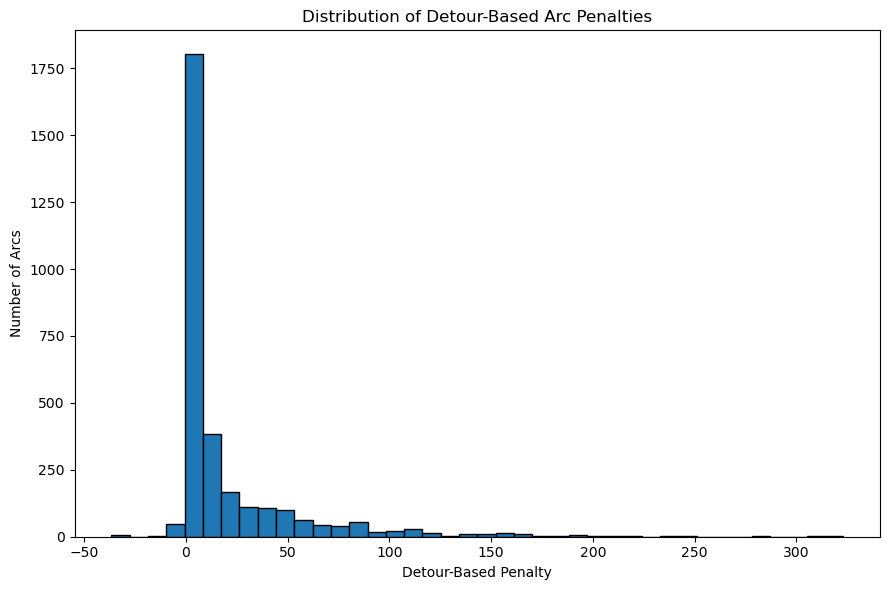

In [21]:
# HISTOGRAM

plt.figure(figsize=(9, 6))

plt.hist(detours["penalty"], bins=40, edgecolor="black")

plt.xlabel("Detour-Based Penalty")
plt.ylabel("Number of Arcs")
plt.title("Distribution of Detour-Based Arc Penalties")

plt.tight_layout()
plt.show()

In [ ]:
# SAVE RESULTS

penalty_df.to_csv( "external_network_detour_penalties.csv", index=False)
print("\nSaved external_network_detour_penalties.csv")

In [23]:
od_results = []

for s in supply_nodes:
    for t in demand_nodes:

        path_exists = nx.has_path(G, s, t)

        if path_exists:
            shortest_cost = nx.shortest_path_length(G,source=s,target=t,weight="cost")
            path = nx.shortest_path(G,source=s,target=t,weight="cost")
            path_arcs = len(path) - 1

        else:
            shortest_cost = np.inf
            path_arcs = None

        od_results.append({
            "source": s,
            "sink": t,
            "path_exists": path_exists,
            "shortest_path_cost": shortest_cost,
            "shortest_path_arcs": path_arcs})


od_df = pd.DataFrame(od_results)

print("\nSupply-demand OD pairs:")
print(od_df)

print("\nReachable pairs:")
print(f"{od_df['path_exists'].sum()} / {len(od_df)}")

od_df.to_csv("external_network_od_pairs.csv", index=False)


Supply-demand OD pairs:
    source  sink  path_exists  shortest_path_cost  shortest_path_arcs
0        1     6         True          694.054024                  63
1        1     7         True          184.159473                  22
2        1     8         True          159.905843                  24
3        1     9         True          160.656519                  26
4        1  1077         True          803.250811                  62
5        2     6         True          418.984733                  35
6        2     7         True          201.887737                  22
7        2     8         True          274.522361                  39
8        2     9         True          274.912421                  39
9        2  1077         True          574.482408                  47
10       3     6         True          189.226226                  20
11       3     7         True          368.826401                  27
12       3     8         True          477.858833                

In [33]:
finite_penalties = penalty_df.loc[penalty_df["alternative_exists"], "penalty"].clip(lower=1)

print(finite_penalties.describe(percentiles=[0.90, 0.95, 0.975, 0.99]))

count    3100.000000
mean       21.052089
std        37.924962
min         1.000000
50%         5.136765
90%        62.129143
95%        95.924230
97.5%     138.793438
99%       188.164105
max       323.052188
Name: penalty, dtype: float64


In [35]:
finite_penalties = penalty_df.loc[penalty_df["alternative_exists"], "penalty"].clip(lower=1)

fallback_penalty = finite_penalties.quantile(0.95)

print("Fallback penalty:", fallback_penalty)

Fallback penalty: 95.924229924


In [37]:
penalty_df["final_penalty"] = penalty_df["penalty"].clip(lower=1)

penalty_df.loc[~penalty_df["alternative_exists"], "final_penalty"] = fallback_penalty

In [39]:
print(penalty_df["final_penalty"].describe(percentiles=[0.90, 0.95, 0.99]))

count    3250.000000
mean       24.507727
std        40.233874
min         1.000000
50%         5.780724
90%        88.848981
95%        95.924230
99%       185.098412
max       323.052188
Name: final_penalty, dtype: float64


In [41]:
print(penalty_df.groupby("alternative_exists")["final_penalty"].describe())

                     count       mean           std       min        25%  \
alternative_exists                                                         
False                150.0  95.924230  9.980924e-14  95.92423  95.924230   
True                3100.0  21.052089  3.792496e+01   1.00000   1.556916   

                          50%        75%         max  
alternative_exists                                    
False               95.924230  95.924230   95.924230  
True                 5.136765  20.502396  323.052188  


In [43]:
penalty_df.head()

,from_node,to_node,transport_mode,cost,alternative_cost,alternative_exists,penalty,final_penalty
0,1,697,road,1.431627,inf,False,244592.474234,95.92423
1,2,142,road,0.377831,inf,False,244592.474234,95.92423
2,3,203,road,0.748802,inf,False,244592.474234,95.92423
3,4,332,road,0.636270,inf,False,244592.474234,95.92423
4,5,393,road,3.044945,inf,False,244592.474234,95.92423


In [45]:
arcs.head()

,from_node,to_node,transport_mode,cost,capacity
0,1,697,road,1.431627,144000
1,2,142,road,0.377831,144000
2,3,203,road,0.748802,144000
3,4,332,road,0.636270,144000
4,5,393,road,3.044945,144000


In [47]:
arcs["penalty"] = penalty_df["final_penalty"].values

In [49]:
print(arcs[["penalty"]].describe())

           penalty
count  3250.000000
mean     24.507727
std      40.233874
min       1.000000
25%       1.689498
50%       5.780724
75%      28.168977
max     323.052188
   from_node  to_node transport_mode      cost  capacity   penalty
0          1      697           road  1.431627    144000  95.92423
1          2      142           road  0.377831    144000  95.92423
2          3      203           road  0.748802    144000  95.92423
3          4      332           road  0.636270    144000  95.92423
4          5      393           road  3.044945    144000  95.92423


In [51]:
arcs.head()

,from_node,to_node,transport_mode,cost,capacity,penalty
0,1,697,road,1.431627,144000,95.92423
1,2,142,road,0.377831,144000,95.92423
2,3,203,road,0.748802,144000,95.92423
3,4,332,road,0.636270,144000,95.92423
4,5,393,road,3.044945,144000,95.92423


In [53]:
arcs.to_csv("arc_data_with_penalties.csv", index=False)

In [55]:
print(len(arcs))
print(len(penalty_df))

3250
3250


In [57]:
print(arcs.columns.tolist())
print(penalty_df.columns.tolist())

['from_node', 'to_node', 'transport_mode', 'cost', 'capacity', 'penalty']
['from_node', 'to_node', 'transport_mode', 'cost', 'alternative_cost', 'alternative_exists', 'penalty', 'final_penalty']


In [59]:
same_arcs = (
    arcs[["from_node", "to_node", "transport_mode"]]
    .reset_index(drop=True)
    .equals(
        penalty_df[["from_node", "to_node", "transport_mode"]]
        .reset_index(drop=True)
    )
)

print("Rows align:", same_arcs)

Rows align: False


In [61]:
key_cols = ["from_node", "to_node", "transport_mode"]

print("Duplicate keys in arcs:",
      arcs.duplicated(key_cols).sum())

print("Duplicate keys in penalty_df:",
      penalty_df.duplicated(key_cols).sum())

Duplicate keys in arcs: 0
Duplicate keys in penalty_df: 0


In [63]:
# Keep original arc data but remove the old penalty column
arcs_final = arcs.drop(columns=["penalty"]).copy()

# Merge the newly calculated penalty onto the correct arc
arcs_final = arcs_final.merge(
    penalty_df[key_cols + ["final_penalty"]],
    on=key_cols,
    how="left",
    validate="one_to_one"
)

# Rename final_penalty to penalty
arcs_final = arcs_final.rename(
    columns={"final_penalty": "penalty"}
)

In [65]:
print("Number of original arcs:", len(arcs))
print("Number of final arcs:", len(arcs_final))
print("Missing penalties:", arcs_final["penalty"].isna().sum())

print(
    arcs_final["penalty"].describe(
        percentiles=[0.90, 0.95, 0.99]
    )
)

Number of original arcs: 3250
Number of final arcs: 3250
Missing penalties: 0
count    3250.000000
mean       24.507727
std        40.233874
min         1.000000
50%         5.780724
90%        88.848981
95%        95.924230
99%       185.098412
max       323.052188
Name: penalty, dtype: float64


In [67]:
arcs_final.to_csv(
    "arc_data_with_detour_penalties.csv",
    index=False
)

In [71]:
# Merge the final file back to penalty_df for verification
check = arcs_final.merge(
    penalty_df[
        ["from_node", "to_node", "transport_mode", "final_penalty"]
    ],
    on=["from_node", "to_node", "transport_mode"],
    how="left",
    validate="one_to_one"
)

# Compare the penalty stored in arcs_final against the calculated final penalty
check["penalty_matches"] = (
    check["penalty"] - check["final_penalty"]
).abs() < 1e-10

print(check["penalty_matches"].value_counts())

penalty_matches
True    3250
Name: count, dtype: int64


In [73]:
print("Total arcs:", len(arcs_final))
print("Missing penalties:", arcs_final["penalty"].isna().sum())
print("Duplicate arcs:", arcs_final.duplicated(
    ["from_node", "to_node", "transport_mode"]
).sum())

print("\nFinal penalty summary:")
print(
    arcs_final["penalty"].describe(
        percentiles=[0.90, 0.95, 0.99]
    )
)

Total arcs: 3250
Missing penalties: 0
Duplicate arcs: 0

Final penalty summary:
count    3250.000000
mean       24.507727
std        40.233874
min         1.000000
50%         5.780724
90%        88.848981
95%        95.924230
99%       185.098412
max       323.052188
Name: penalty, dtype: float64


In [75]:
check_no_alt = penalty_df.loc[
    ~penalty_df["alternative_exists"]
]

print("No-alternative arcs:", len(check_no_alt))

print(
    check_no_alt["final_penalty"].value_counts()
)

No-alternative arcs: 150
final_penalty
95.92423    150
Name: count, dtype: int64


In [ ]:
training_data_shortest_path_filtered_pilot_v2.json

In [43]:
import json
import pandas as pd

with open("training_data_shortest_path_filtered_pilot_v2.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# one row per unique underlying graph
graphs = (
    df.drop_duplicates(subset="graph_seed")
      .copy()
)

summary = (
    graphs.groupby(["n_nodes", "density"])
    .agg(
        num_graphs=("graph_seed", "count"),
        hops_mean=("shortest_path_hops", "mean"),
        hops_min=("shortest_path_hops", "min"),
        hops_median=("shortest_path_hops", "median"),
        hops_max=("shortest_path_hops", "max"),
        edge_conn_mean=("edge_connectivity", "mean"),
        edge_conn_min=("edge_connectivity", "min"),
        edge_conn_median=("edge_connectivity", "median"),
        edge_conn_max=("edge_connectivity", "max"),
        attempts_mean=("generation_attempts", "mean"),
        attempts_min=("generation_attempts", "min"),
        attempts_median=("generation_attempts", "median"),
        attempts_max=("generation_attempts", "max"),
    )
    .reset_index()
)

print(summary.to_string(index=False))

 n_nodes  density  num_graphs  hops_mean  hops_min  hops_median  hops_max  edge_conn_mean  edge_conn_min  edge_conn_median  edge_conn_max  attempts_mean  attempts_min  attempts_median  attempts_max
      30      2.0          10        4.5         4          4.0         7             1.5              1               1.0              3            2.1             1              1.5             7
      30      3.0          10        4.3         4          4.0         6             1.9              1               1.5              3            2.7             1              2.0             6
      30      4.0          10        4.0         4          4.0         4             1.7              1               2.0              2            6.5             1              4.0            15
      30      6.0          10        3.0         3          3.0         3             4.0              1               4.0              8            7.2             1              7.0            15
      50  

In [45]:
print(
    graphs[
        [
            "n_nodes",
            "density",
            "shortest_path_hops",
            "edge_connectivity",
            "generation_attempts",
        ]
    ]
    .sort_values(["n_nodes", "density", "generation_attempts"])
    .to_string(index=False)
)

 n_nodes  density  shortest_path_hops  edge_connectivity  generation_attempts
      30      2.0                   4                  3                    1
      30      2.0                   4                  1                    1
      30      2.0                   4                  1                    1
      30      2.0                   4                  1                    1
      30      2.0                   4                  2                    1
      30      2.0                   5                  2                    2
      30      2.0                   4                  2                    2
      30      2.0                   4                  1                    2
      30      2.0                   7                  1                    3
      30      2.0                   5                  1                    7
      30      3.0                   5                  1                    1
      30      3.0                   4                  1        

In [47]:
summary = (
    graphs.groupby(["n_nodes", "density"])
    .agg(
        num_graphs=("graph_seed", "count"),

        hops_mean=("shortest_path_hops", "mean"),
        hops_min=("shortest_path_hops", "min"),
        hops_median=("shortest_path_hops", "median"),
        hops_max=("shortest_path_hops", "max"),

        edge_conn_mean=("edge_connectivity", "mean"),
        edge_conn_min=("edge_connectivity", "min"),
        edge_conn_median=("edge_connectivity", "median"),
        edge_conn_max=("edge_connectivity", "max"),

        attempts_mean=("generation_attempts", "mean"),
        attempts_median=("generation_attempts", "median"),
        attempts_max=("generation_attempts", "max"),
    )
    .reset_index()
)

summary

,n_nodes,density,num_graphs,hops_mean,hops_min,hops_median,hops_max,edge_conn_mean,edge_conn_min,edge_conn_median,edge_conn_max,attempts_mean,attempts_median,attempts_max
0,30,2.0,10,4.5,4,4.0,7,1.5,1,1.0,3,2.1,1.5,7
1,30,3.0,10,4.3,4,4.0,6,1.9,1,1.5,3,2.7,2.0,6
2,30,4.0,10,4.0,4,4.0,4,1.7,1,2.0,2,6.5,4.0,15
3,30,6.0,10,3.0,3,3.0,3,4.0,1,4.0,8,7.2,7.0,15
4,50,2.0,10,5.2,4,4.5,9,1.8,1,2.0,3,1.0,1.0,1
5,50,3.0,10,4.5,4,4.0,6,1.9,1,2.0,4,3.3,2.5,10
6,50,4.0,10,4.2,4,4.0,5,2.3,1,2.0,4,7.7,2.0,23
7,50,6.0,10,3.3,3,3.0,5,3.5,1,3.5,6,1.6,1.0,3
8,75,2.0,10,6.3,5,5.5,11,1.5,1,1.5,2,1.0,1.0,1
9,75,3.0,10,5.5,5,5.5,6,1.4,1,1.0,3,2.8,2.0,9


In [49]:
graph_stats = []

for seed, sample in unique_graphs.items():

    # Reconstruct directed graph
    G = nx.DiGraph()
    G.add_nodes_from(range(sample["n_nodes"]))
    G.add_edges_from(zip(sample["u"], sample["v"]))

    s = sample["source"]
    t = sample["sink"]

    # Basic graph information
    n = G.number_of_nodes()
    m = G.number_of_edges()

    # Source-sink edge connectivity
    edge_connectivity = nx.edge_connectivity(G, s, t)

    # Shortest path in number of arcs, ignoring costs for now
    shortest_path_hops = nx.shortest_path_length(G, source=s, target=t)

    # Source/sink degrees
    source_out_degree = G.out_degree(s)
    sink_in_degree = G.in_degree(t)

    graph_stats.append({
        "graph_seed": seed,
        "n_nodes": n,
        "n_arcs": m,
        "density": m / n,
        "edge_connectivity": edge_connectivity,
        "shortest_path_hops": shortest_path_hops,
        "source_out_degree": source_out_degree,
        "sink_in_degree": sink_in_degree,
    })

stats = pd.DataFrame(graph_stats)

stats.head()

,graph_seed,n_nodes,n_arcs,density,edge_connectivity,shortest_path_hops,source_out_degree,sink_in_degree
0,3007501,30,75,2.5,2,3,4,2
1,3007502,30,75,2.5,2,4,2,3
2,3007503,30,75,2.5,2,4,3,2
3,3007504,30,75,2.5,2,3,2,4
4,3007505,30,75,2.5,3,1,6,3


In [5]:
summary = (
    stats
    .groupby(["n_nodes", "density"])
    .agg(
        num_graphs=("graph_seed", "count"),

        edge_conn_mean=("edge_connectivity", "mean"),
        edge_conn_min=("edge_connectivity", "min"),
        edge_conn_median=("edge_connectivity", "median"),
        edge_conn_max=("edge_connectivity", "max"),

        path_hops_mean=("shortest_path_hops", "mean"),
        path_hops_min=("shortest_path_hops", "min"),
        path_hops_median=("shortest_path_hops", "median"),
        path_hops_max=("shortest_path_hops", "max"),

        source_degree_mean=("source_out_degree", "mean"),
        sink_degree_mean=("sink_in_degree", "mean"),
    )
    .reset_index()
)

summary

,n_nodes,density,num_graphs,edge_conn_mean,edge_conn_min,edge_conn_median,edge_conn_max,path_hops_mean,path_hops_min,path_hops_median,path_hops_max,source_degree_mean,sink_degree_mean
0,30,2.500000,50,1.70,1,2.0,3,3.60,1,3.0,8,2.60,2.54
1,30,4.000000,50,3.10,1,3.0,6,2.66,1,3.0,5,4.10,3.80
2,30,6.000000,50,4.60,1,5.0,8,2.06,1,2.0,3,6.06,5.82
3,50,2.500000,50,1.82,1,2.0,4,3.96,1,4.0,6,2.76,2.52
4,50,4.000000,50,3.12,1,3.0,7,2.94,1,3.0,6,4.12,3.96
5,50,6.000000,50,4.76,2,5.0,10,2.24,1,2.0,4,5.72,6.32
6,75,2.506667,50,1.78,1,2.0,5,4.76,1,5.0,8,2.86,2.54
7,75,4.000000,50,3.20,1,3.0,6,3.18,1,3.0,6,4.66,3.76
8,75,6.000000,50,4.14,1,4.0,8,2.42,1,2.0,5,5.40,5.72


In [7]:
stats.groupby("density")["edge_connectivity"].describe()

,count,mean,std,min,25%,50%,75%,max
density,,,,,,,,
2.500000,100.0,1.76,0.780054,1.0,1.0,2.0,2.0,4.0
2.506667,50.0,1.78,0.932191,1.0,1.0,2.0,2.0,5.0
4.000000,150.0,3.14,1.226278,1.0,2.0,3.0,4.0,7.0
6.000000,150.0,4.50,1.697808,1.0,3.0,4.0,6.0,10.0


In [9]:
stats.groupby(["n_nodes", "density"])["edge_connectivity"].value_counts().sort_index()

n_nodes  density   edge_connectivity
30       2.500000  1                    24
                   2                    17
                   3                     9
         4.000000  1                     4
                   2                    11
                   3                    19
                   4                    10
                   5                     4
                   6                     2
         6.000000  1                     2
                   2                     3
                   3                    10
                   4                     8
                   5                    10
                   6                    11
                   7                     4
                   8                     2
50       2.500000  1                    19
                   2                    23
                   3                     6
                   4                     2
         4.000000  1                     5
                 

In [19]:
hop_distribution = (
    stats
    .groupby(["n_nodes", "density", "shortest_path_hops"])
    .size()
    .reset_index(name="count")
)

hop_distribution

,n_nodes,density,shortest_path_hops,count
0,30,2.500000,1,2
1,30,2.500000,2,6
2,30,2.500000,3,20
3,30,2.500000,4,12
4,30,2.500000,5,6
5,30,2.500000,6,2
6,30,2.500000,8,2
7,30,4.000000,1,2
8,30,4.000000,2,17
9,30,4.000000,3,28


In [21]:
short_path_summary = (
    stats
    .assign(
        hops_le_2 = stats["shortest_path_hops"] <= 2,
        hops_le_3 = stats["shortest_path_hops"] <= 3
    )
    .groupby(["n_nodes", "density"])
    .agg(
        pct_hops_le_2=("hops_le_2", "mean"),
        pct_hops_le_3=("hops_le_3", "mean"),
        mean_hops=("shortest_path_hops", "mean")
    )
    .reset_index()
)

short_path_summary["pct_hops_le_2"] *= 100
short_path_summary["pct_hops_le_3"] *= 100

short_path_summary

,n_nodes,density,pct_hops_le_2,pct_hops_le_3,mean_hops
0,30,2.500000,16.0,56.0,3.60
1,30,4.000000,38.0,94.0,2.66
2,30,6.000000,72.0,100.0,2.06
3,50,2.500000,8.0,34.0,3.96
4,50,4.000000,36.0,66.0,2.94
5,50,6.000000,62.0,96.0,2.24
6,75,2.506667,4.0,26.0,4.76
7,75,4.000000,22.0,72.0,3.18
8,75,6.000000,54.0,88.0,2.42


## Max Flow Validation

In [132]:
with open("training_data_max_flow.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.groupby(
    ["n_nodes", "n_arcs", "density", "attack_limit"]
).size().unstack(fill_value=0)

attack_limit              1   2   3   4   5
n_nodes n_arcs density                     
30      75     2.500000  50  50  50  50  50
        120    4.000000  50  50  50  50  50
        180    6.000000  50  50  50  50  50
50      125    2.500000  50  50  50  50  50
        200    4.000000  50  50  50  50  50
        300    6.000000  50  50  50  50  50
75      188    2.506667  50  50  50  50  50
        300    4.000000  50  50  50  50  50
        450    6.000000  50  50  50  50  50

In [134]:
counts = (
    df.groupby(["n_nodes", "n_arcs", "attack_limit"])
      .size()
      .reset_index(name="count")
)

counts

,n_nodes,n_arcs,attack_limit,count
0,30,75,1,50
1,30,75,2,50
2,30,75,3,50
3,30,75,4,50
4,30,75,5,50
5,30,120,1,50
6,30,120,2,50
7,30,120,3,50
8,30,120,4,50
9,30,120,5,50


In [136]:
data[0].keys()

dict_keys(['n_nodes', 'n_arcs', 'density', 'source', 'sink', 'attack_limit', 'problem_type', 'u', 'v', 'penalty', 'attack', 'max_flow', 'penalty_high', 'mip_solve_time', 'solver_status', 'termination_condition', 'capacity', 'capacity_high', 'baseline_max_flow', 'graph_seed', 'replication', 'attack_budget'])

In [138]:
instance = data[0]

G = nx.DiGraph()

for u, v, capacity in zip(
    instance["u"],
    instance["v"],
    instance["capacity"]
):
    G.add_edge(
        u,
        v,
        capacity=capacity
    )

source = instance["source"]
sink = instance["sink"]

baseline = nx.maximum_flow_value(
    G,
    source,
    sink,
    capacity="capacity"
)

print("Recomputed baseline:", baseline)
print("Saved baseline:", instance["baseline_max_flow"])

Recomputed baseline: 42
Saved baseline: 42.0


In [140]:
G_interdicted = G.copy()

for u, v, attack in zip(
    instance["u"],
    instance["v"],
    instance["attack"]
):
    if attack == 1:
        G_interdicted.remove_edge(u, v)

interdicted_flow = nx.maximum_flow_value(
    G_interdicted,
    source,
    sink,
    capacity="capacity"
)

print("Recomputed interdicted flow:", interdicted_flow)
print("Saved MIP objective:", instance["max_flow"])

Recomputed interdicted flow: 31
Saved MIP objective: 31.0


In [142]:
results = []

for i, instance in enumerate(data):

    G = nx.DiGraph()

    for u, v, capacity in zip(
        instance["u"],
        instance["v"],
        instance["capacity"]
    ):
        G.add_edge(
            u,
            v,
            capacity=capacity
        )

    source = instance["source"]
    sink = instance["sink"]

    baseline = nx.maximum_flow_value(
        G,
        source,
        sink,
        capacity="capacity"
    )

    G_interdicted = G.copy()

    for u, v, attack in zip(
        instance["u"],
        instance["v"],
        instance["attack"]
    ):
        if attack == 1:
            G_interdicted.remove_edge(u, v)

    attacked = nx.maximum_flow_value(
        G_interdicted,
        source,
        sink,
        capacity="capacity"
    )

    saved = instance["max_flow"]

    results.append({
        "index": i,
        "graph_seed": instance["graph_seed"],
        "attack_limit": instance["attack_limit"],
        "density": instance["density"],
        "baseline": baseline,
        "recomputed_objective": attacked,
        "saved_objective": saved,
        "matches": np.isclose(attacked, saved)
    })

check_df = pd.DataFrame(results)

In [144]:
check_df["matches"].value_counts()

matches
True    2250
Name: count, dtype: int64

In [148]:
check_df["flow_reduction"] = (
    check_df["baseline"]
    - check_df["recomputed_objective"]
)

check_df["relative_flow_reduction"] = (
    check_df["flow_reduction"]
    / check_df["baseline"]
)

In [150]:
check_df.groupby("attack_limit").agg(
    avg_baseline=("baseline", "mean"),
    avg_residual_flow=("recomputed_objective", "mean"),
    avg_flow_reduction=("flow_reduction", "mean"),
    avg_relative_reduction=("relative_flow_reduction", "mean")
)

,avg_baseline,avg_residual_flow,avg_flow_reduction,avg_relative_reduction
attack_limit,,,,
1,58.024444,41.686667,16.337778,0.294120
2,58.024444,28.404444,29.620000,0.527645
3,58.024444,17.804444,40.220000,0.709148
4,58.024444,9.795556,48.228889,0.843802
5,58.024444,4.331111,53.693333,0.933330


In [152]:
violations = []

for seed, group in check_df.groupby("graph_seed"):

    group = group.sort_values("attack_limit")

    objectives = np.round(
        group["saved_objective"].to_numpy(),
        6
    )

    # max-flow objective should not increase as K increases
    if np.any(np.diff(objectives) > 0):
        violations.append(seed)

print("Monotonicity violations:", len(violations))

Monotonicity violations: 0


## Shortest Path Validation

In [29]:
with open("training_data_shortest_path.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [48]:
baseline_disconnected = []

for instance in data:
    G = nx.DiGraph()

    G.add_nodes_from(range(instance["n_nodes"]))

    for u, v, dist in zip(
        instance["u"],
        instance["v"],
        instance["dist"]
    ):
        G.add_edge(u, v, weight=dist)

    baseline_disconnected.append(
        not nx.has_path(
            G,
            instance["source"],
            instance["sink"]
        )
    )

print("Baseline disconnected rate:")
print(np.mean(baseline_disconnected))

Baseline disconnected rate:
0.0


In [54]:
instance = data[0]

G = nx.DiGraph()

for u, v, dist in zip(
    instance["u"],
    instance["v"],
    instance["dist"]
):
    G.add_edge(u, v, weight=dist)

source = instance["source"]
sink = instance["sink"]

baseline = nx.shortest_path_length(
    G,
    source,
    sink,
    weight="weight"
)

print("Recomputed baseline:", baseline)
print("Saved baseline:", instance["path_length"])

Recomputed baseline: 6
Saved baseline: 12.0


In [56]:
G_interdicted = nx.DiGraph()

for u, v, dist, penalty, attack in zip(
    instance["u"],
    instance["v"],
    instance["dist"],
    instance["penalty"],
    instance["attack"]
):
    new_dist = dist + penalty * attack

    G_interdicted.add_edge(
        u,
        v,
        weight=new_dist
    )

interdicted_length = nx.shortest_path_length(
    G_interdicted,
    source,
    sink,
    weight="weight"
)

print("Baseline shortest path:", baseline)
print("Recomputed interdicted path:", interdicted_length)
print("Saved MIP path_length:", instance["path_length"])

Baseline shortest path: 6
Recomputed interdicted path: 12
Saved MIP path_length: 12.0


In [58]:
results = []

for i, instance in enumerate(data):

    G = nx.DiGraph()
    G_interdicted = nx.DiGraph()

    for u, v, dist, penalty, attack in zip(
        instance["u"],
        instance["v"],
        instance["dist"],
        instance["penalty"],
        instance["attack"]
    ):
        # Original graph
        G.add_edge(
            u,
            v,
            weight=dist
        )

        # Same graph after interdiction penalties
        G_interdicted.add_edge(
            u,
            v,
            weight=dist + penalty * attack
        )

    source = instance["source"]
    sink = instance["sink"]

    baseline = nx.shortest_path_length(
        G,
        source,
        sink,
        weight="weight"
    )

    attacked = nx.shortest_path_length(
        G_interdicted,
        source,
        sink,
        weight="weight"
    )

    results.append({
        "index": i,
        "graph_seed": instance["graph_seed"],
        "attack_limit": instance["attack_limit"],
        "baseline": baseline,
        "recomputed_objective": attacked,
        "saved_objective": instance["path_length"],
        "matches": np.isclose(
            attacked,
            instance["path_length"]
        )
    })

check_df = pd.DataFrame(results)

In [60]:
check_df["matches"].value_counts()

matches
True    2250
Name: count, dtype: int64

In [62]:
check_df["path_increase"] = (
    check_df["recomputed_objective"] -
    check_df["baseline"]
)

check_df["relative_path_increase"] = (
    check_df["path_increase"] /
    check_df["baseline"]
)

In [64]:
check_df.groupby("attack_limit").agg(
    avg_baseline=("baseline", "mean"),
    avg_interdicted=("recomputed_objective", "mean"),
    avg_path_increase=("path_increase", "mean"),
    avg_relative_increase=("relative_path_increase", "mean")
)

,avg_baseline,avg_interdicted,avg_path_increase,avg_relative_increase
attack_limit,,,,
1,13.651111,18.122222,4.471111,0.485561
2,13.651111,20.951111,7.300000,0.730154
3,13.651111,22.926667,9.275556,0.885688
4,13.651111,24.584444,10.933333,1.018333
5,13.651111,25.795556,12.144444,1.115512


In [52]:
instance.keys()

dict_keys(['n_nodes', 'n_arcs', 'density', 'source', 'sink', 'attack_limit', 'problem_type', 'u', 'v', 'penalty', 'attack', 'path_length', 'penalty_high', 'mip_solve_time', 'solver_status', 'termination_condition', 'dist', 'cost_high', 'graph_seed', 'replication', 'attack_budget'])

In [88]:
negative_diffs = []

for seed, group in check_df.groupby("graph_seed"):
    group = group.sort_values("attack_limit")

    objectives = group["saved_objective"].to_numpy()
    ks = group["attack_limit"].to_numpy()
    diffs = np.diff(objectives)

    for i, diff in enumerate(diffs):
        if diff < 0:
            negative_diffs.append({
                "graph_seed": seed,
                "from_K": ks[i],
                "to_K": ks[i + 1],
                "from_objective": objectives[i],
                "to_objective": objectives[i + 1],
                "difference": diff
            })

negative_df = pd.DataFrame(negative_diffs)

negative_df.sort_values("difference")

,graph_seed,from_K,to_K,from_objective,to_objective,difference
0,5012521,4,5,47.0,47.0,-2.756742e-07


In [76]:
violations

[5012521]

In [78]:
bad_seed = violations[0]

check_df[
    check_df["graph_seed"] == bad_seed
].sort_values("attack_limit")

,index,graph_seed,attack_limit,baseline,recomputed_objective,saved_objective,matches,path_increase,relative_path_increase
170,170,5012521,1,32,38,38.0,True,6,0.18750
620,620,5012521,2,32,42,42.0,True,10,0.31250
1070,1070,5012521,3,32,44,44.0,True,12,0.37500
1520,1520,5012521,4,32,47,47.0,True,15,0.46875
1970,1970,5012521,5,32,47,47.0,True,15,0.46875


## Min Cost Flow Validation

In [90]:
with open("training_data_min_cost_flow.json", "r") as f:
    data = json.load(f)

instance = data[0]

instance.keys()

dict_keys(['n_nodes', 'n_arcs', 'density', 'source', 'sink', 'attack_limit', 'problem_type', 'u', 'v', 'penalty', 'attack', 'min_cost_flow', 'penalty_high', 'mip_solve_time', 'solver_status', 'termination_condition', 'dist', 'cost_high', 'capacity', 'capacity_high', 'flow_demand', 'graph_seed', 'replication', 'attack_budget'])

In [106]:
instance = data[0]

G = nx.DiGraph()

for u, v, cost, capacity in zip(
    instance["u"],
    instance["v"],
    instance["dist"],
    instance["capacity"]
):
    G.add_edge(
        u,
        v,
        weight=cost,
        capacity=capacity
    )

source = instance["source"]
sink = instance["sink"]
flow_demand = instance["flow_demand"]

# NetworkX convention:
# negative demand = supply
# positive demand = demand
for node in G.nodes():
    G.nodes[node]["demand"] = 0

G.nodes[source]["demand"] = -flow_demand
G.nodes[sink]["demand"] = flow_demand

baseline = nx.min_cost_flow_cost(
    G,
    demand="demand",
    capacity="capacity",
    weight="weight"
)

print("Recomputed baseline cost:", baseline)

Recomputed baseline cost: 36


In [108]:
G_interdicted = nx.DiGraph()

for u, v, cost, capacity, penalty, attack in zip(
    instance["u"],
    instance["v"],
    instance["dist"],
    instance["capacity"],
    instance["penalty"],
    instance["attack"]
):
    interdicted_cost = cost + penalty * attack

    G_interdicted.add_edge(
        u,
        v,
        weight=interdicted_cost,
        capacity=capacity
    )

for node in G_interdicted.nodes():
    G_interdicted.nodes[node]["demand"] = 0

G_interdicted.nodes[source]["demand"] = -flow_demand
G_interdicted.nodes[sink]["demand"] = flow_demand

attacked = nx.min_cost_flow_cost(
    G_interdicted,
    demand="demand",
    capacity="capacity",
    weight="weight"
)

print("Baseline cost:", baseline)
print("Recomputed interdicted cost:", attacked)
print("Saved MIP objective:", instance["min_cost_flow"])

Baseline cost: 36
Recomputed interdicted cost: 72
Saved MIP objective: 72.0


In [110]:
results = []

for i, instance in enumerate(data):

    G = nx.DiGraph()
    G_interdicted = nx.DiGraph()

    for u, v, cost, capacity, penalty, attack in zip(
        instance["u"],
        instance["v"],
        instance["dist"],
        instance["capacity"],
        instance["penalty"],
        instance["attack"]
    ):

        G.add_edge(
            u,
            v,
            weight=cost,
            capacity=capacity
        )

        G_interdicted.add_edge(
            u,
            v,
            weight=cost + penalty * attack,
            capacity=capacity
        )

    source = instance["source"]
    sink = instance["sink"]
    flow_demand = instance["flow_demand"]

    for node in G.nodes():
        G.nodes[node]["demand"] = 0
        G_interdicted.nodes[node]["demand"] = 0

    G.nodes[source]["demand"] = -flow_demand
    G.nodes[sink]["demand"] = flow_demand

    G_interdicted.nodes[source]["demand"] = -flow_demand
    G_interdicted.nodes[sink]["demand"] = flow_demand

    baseline = nx.min_cost_flow_cost(
        G,
        demand="demand",
        capacity="capacity",
        weight="weight"
    )

    attacked = nx.min_cost_flow_cost(
        G_interdicted,
        demand="demand",
        capacity="capacity",
        weight="weight"
    )

    saved = instance["min_cost_flow"]

    results.append({
        "index": i,
        "graph_seed": instance["graph_seed"],
        "attack_limit": instance["attack_limit"],
        "baseline": baseline,
        "recomputed_objective": attacked,
        "saved_objective": saved,
        "matches": np.isclose(attacked, saved)
    })

check_df = pd.DataFrame(results)

In [112]:
check_df["matches"].value_counts()

matches
True    2250
Name: count, dtype: int64

In [116]:
check_df["cost_increase"] = (
    check_df["recomputed_objective"]
    - check_df["baseline"]
)

check_df["relative_cost_increase"] = (
    check_df["cost_increase"]
    / check_df["baseline"]
)

In [118]:
check_df.groupby("attack_limit").agg(
    avg_baseline=("baseline", "mean"),
    avg_interdicted=("recomputed_objective", "mean"),
    avg_cost_increase=("cost_increase", "mean"),
    avg_relative_increase=("relative_cost_increase", "mean")
)

,avg_baseline,avg_interdicted,avg_cost_increase,avg_relative_increase
attack_limit,,,,
1,217.068889,266.473333,49.404444,0.301675
2,217.068889,299.808889,82.740000,0.480546
3,217.068889,325.771111,108.702222,0.614866
4,217.068889,345.515556,128.446667,0.714200
5,217.068889,362.468889,145.400000,0.797616


In [120]:
violations = []

for seed, group in check_df.groupby("graph_seed"):

    group = group.sort_values("attack_limit")

    # Your costs/penalties are integer-valued, so round away
    # solver floating-point noise before checking monotonicity.
    objectives = np.round(
        group["saved_objective"].to_numpy()
    )

    if np.any(np.diff(objectives) < 0):
        violations.append(seed)

print("Monotonicity violations:", len(violations))

Monotonicity violations: 0
